# Notebook 01 — Exploración de Datos (EDA)

**Responsable:** Estudiante A  
**Objetivo:** Comprender la estructura y características del dataset TMDB antes de preprocesar.

## Contenido
1. Carga del dataset
2. Inspección general (shape, tipos, valores nulos)
3. Distribución de la variable objetivo (géneros)
4. Análisis de variables numéricas
5. Análisis de variables de texto (géneros, keywords, cast)
6. Correlaciones
7. Hallazgos clave

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import os
import sys

# Agregar el directorio raíz al path para importar src/
sys.path.insert(0, os.path.abspath('..'))

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1. Carga del Dataset

In [2]:
# Cargar los dos archivos CSV
movies  = pd.read_csv('../data/raw/tmdb_5000_movies.csv')
credits = pd.read_csv('../data/raw/tmdb_5000_credits.csv')

print(f'Movies:  {movies.shape[0]} filas, {movies.shape[1]} columnas')
print(f'Credits: {credits.shape[0]} filas, {credits.shape[1]} columnas')
movies.head(3)

Movies:  4803 filas, 20 columnas
Credits: 4803 filas, 4 columnas


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [3]:
# Unir los dos DataFrames por ID de película
# En movies: columna 'id'; en credits: columna 'movie_id'
credits = credits.rename(columns={'movie_id': 'id'})
df = movies.merge(credits[['id', 'cast', 'crew']], on='id', how='left')
print(f'Dataset combinado: {df.shape}')
df.columns.tolist()

Dataset combinado: (4803, 22)


['budget',
 'genres',
 'homepage',
 'id',
 'keywords',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'production_companies',
 'production_countries',
 'release_date',
 'revenue',
 'runtime',
 'spoken_languages',
 'status',
 'tagline',
 'title',
 'vote_average',
 'vote_count',
 'cast',
 'crew']

## 2. Inspección General

In [4]:
# Tipos de datos
df.dtypes

budget                    int64
genres                      str
homepage                    str
id                        int64
keywords                    str
original_language           str
original_title              str
overview                    str
popularity              float64
production_companies        str
production_countries        str
release_date                str
revenue                   int64
runtime                 float64
spoken_languages            str
status                      str
tagline                     str
title                       str
vote_average            float64
vote_count                int64
cast                        str
crew                        str
dtype: object

In [5]:
# Valores nulos por columna
nulos = df.isnull().sum()
print(nulos[nulos > 0])
print(f'\nTotal de valores nulos: {nulos.sum()}')

homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64

Total de valores nulos: 3941


In [6]:
# Estadísticas descriptivas de columnas numéricas
cols_num = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']
df[cols_num].describe().round(2)

,budget,revenue,runtime,vote_average,vote_count,popularity
count,4.803000e+03,4.803000e+03,4801.00,4803.00,4803.00,4803.00
mean,2.904504e+07,8.226064e+07,106.88,6.09,690.22,21.49
std,4.072239e+07,1.628571e+08,22.61,1.19,1234.59,31.82
min,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00
25%,7.900000e+05,0.000000e+00,94.00,5.60,54.00,4.67
50%,1.500000e+07,1.917000e+07,103.00,6.20,235.00,12.92
75%,4.000000e+07,9.291719e+07,118.00,6.80,737.00,28.31
max,3.800000e+08,2.787965e+09,338.00,10.00,13752.00,875.58


## 3. Distribución de Géneros

La columna `genres` contiene strings JSON-like (listas de dicts). Usamos `ast.literal_eval` para parsearlos.

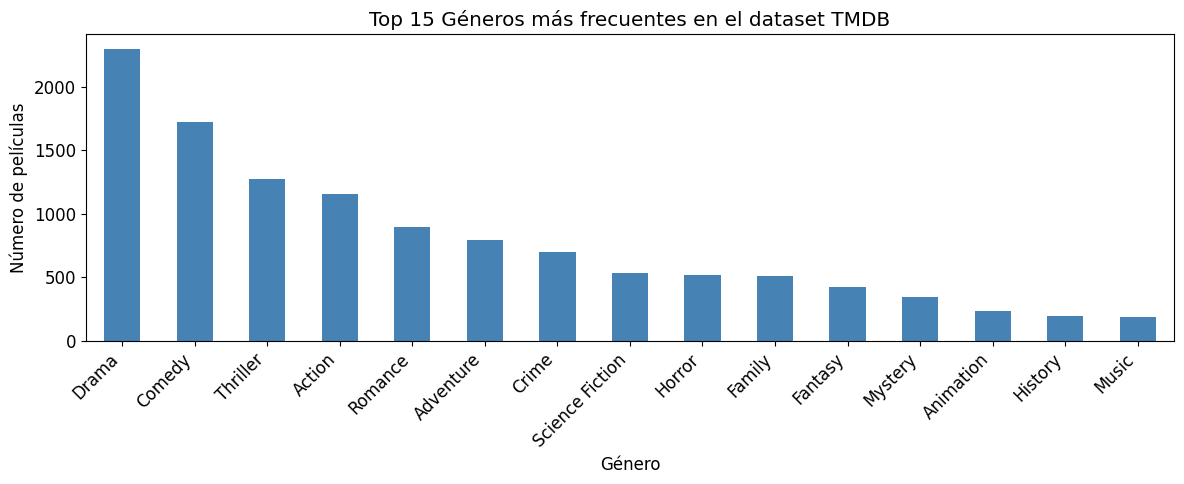

Drama              2297
Comedy             1722
Thriller           1274
Action             1154
Romance             894
Adventure           790
Crime               696
Science Fiction     535
Horror              519
Family              513
Fantasy             424
Mystery             348
Animation           234
History             197
Music               185
Name: count, dtype: int64


In [7]:
def extract_names(value):
    """Extrae nombres de una columna JSON-like del dataset TMDB."""
    try:
        return [item['name'] for item in ast.literal_eval(value)]
    except:
        return []

# Contar frecuencia de géneros
all_genres = [g for genres in df['genres'].apply(extract_names) for g in genres]
genre_counts = pd.Series(all_genres).value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 Géneros más frecuentes en el dataset TMDB')
ax.set_xlabel('Género')
ax.set_ylabel('Número de películas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/genre_distribution.png', dpi=150)
plt.show()
print(genre_counts.head(15))

## 4. Análisis de Variables Numéricas

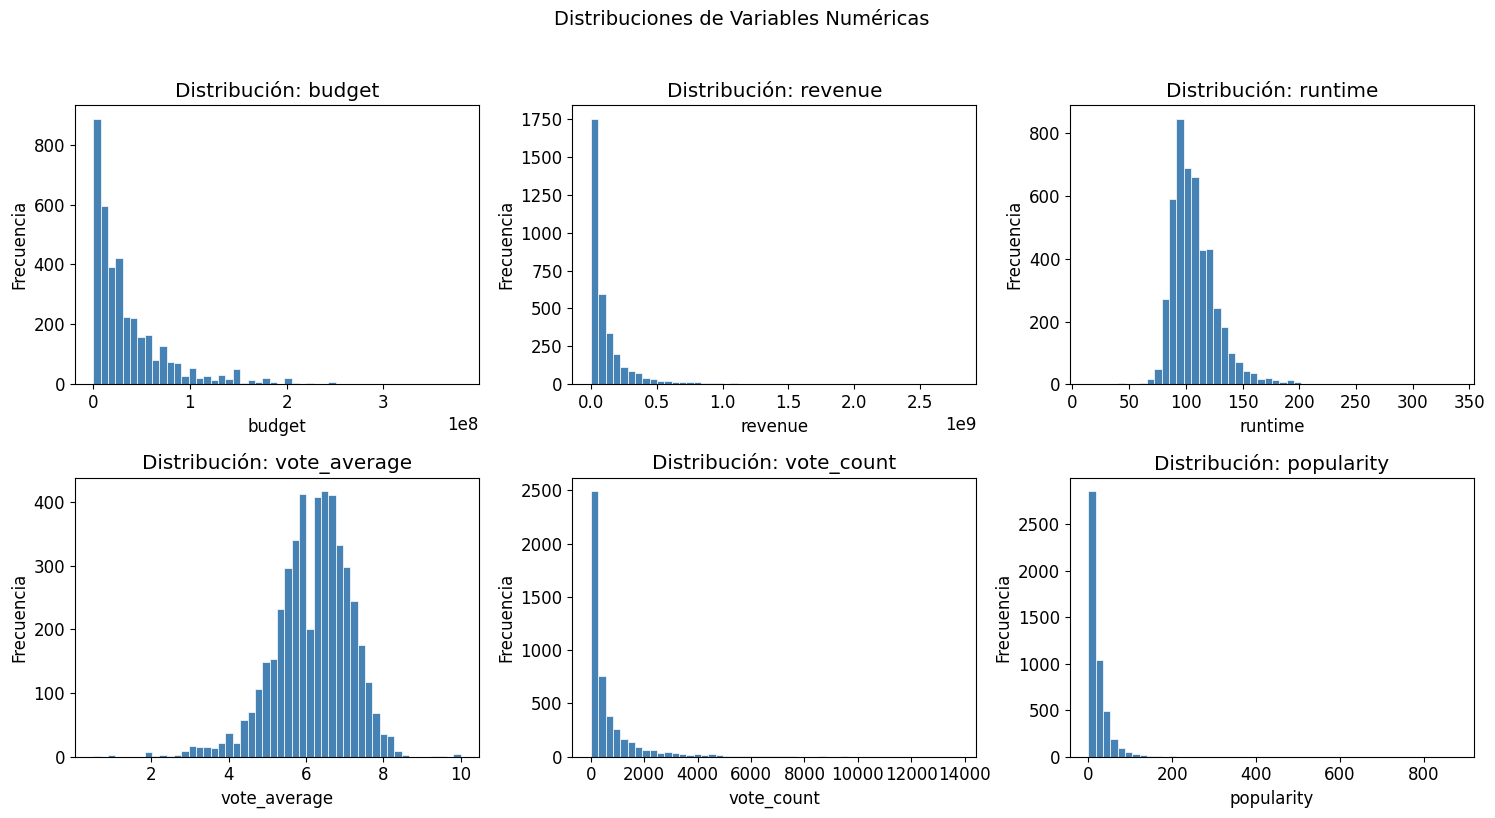

In [8]:
# Histogramas de variables numéricas clave
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    data = df[col].dropna()
    data = data[data > 0]  # excluir ceros (datos faltantes codificados)
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones de Variables Numéricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/numeric_distributions.png', dpi=150)
plt.show()

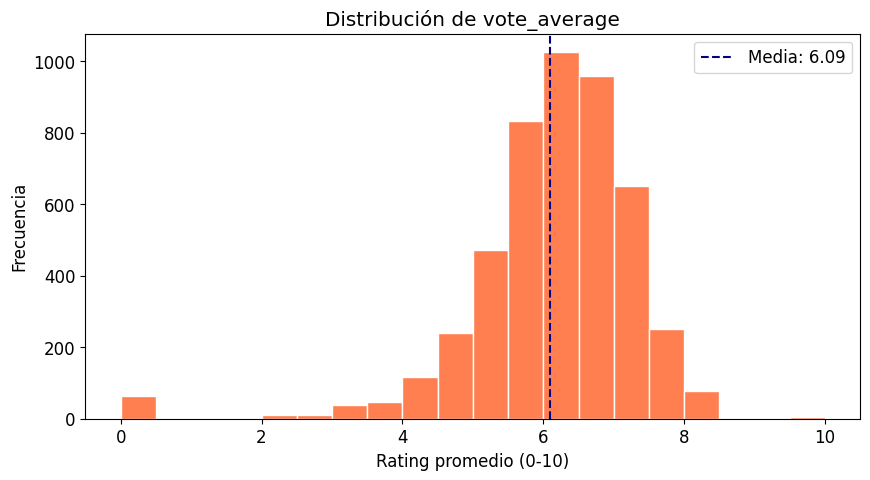

In [9]:
# Distribución de vote_average (la más relevante para CF)
fig, ax = plt.subplots()
ax.hist(df['vote_average'], bins=20, color='coral', edgecolor='white')
ax.axvline(df['vote_average'].mean(), color='navy', linestyle='--', label=f'Media: {df["vote_average"].mean():.2f}')
ax.set_title('Distribución de vote_average')
ax.set_xlabel('Rating promedio (0-10)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.savefig('../reports/figures/vote_average_dist.png', dpi=150)
plt.show()

## 5. Keywords y Cast más Frecuentes

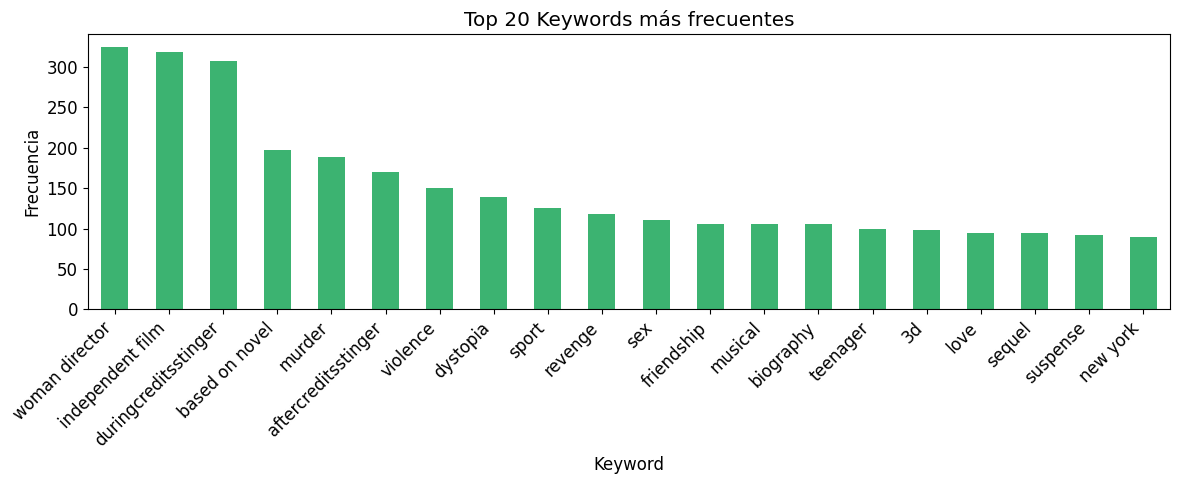

In [10]:
# Top keywords
all_keywords = [k for kws in df['keywords'].apply(extract_names) for k in kws]
kw_counts = pd.Series(all_keywords).value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
kw_counts.head(20).plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Top 20 Keywords más frecuentes')
ax.set_xlabel('Keyword')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/top_keywords.png', dpi=150)
plt.show()

In [11]:
# Top actores (cast)
all_actors = [a for cast in df['cast'].apply(extract_names) for a in cast]
actor_counts = pd.Series(all_actors).value_counts()

print('Top 15 actores con más apariciones:')
print(actor_counts.head(15).to_string())

Top 15 actores con más apariciones:
Samuel L. Jackson    67
Robert De Niro       57
Bruce Willis         51
Matt Damon           48
Morgan Freeman       46
Steve Buscemi        43
Liam Neeson          41
Johnny Depp          40
Owen Wilson          40
John Goodman         39
Nicolas Cage         39
Alec Baldwin         39
Willem Dafoe         38
Jim Broadbent        38
Stanley Tucci        38


## 6. Mapa de Correlaciones

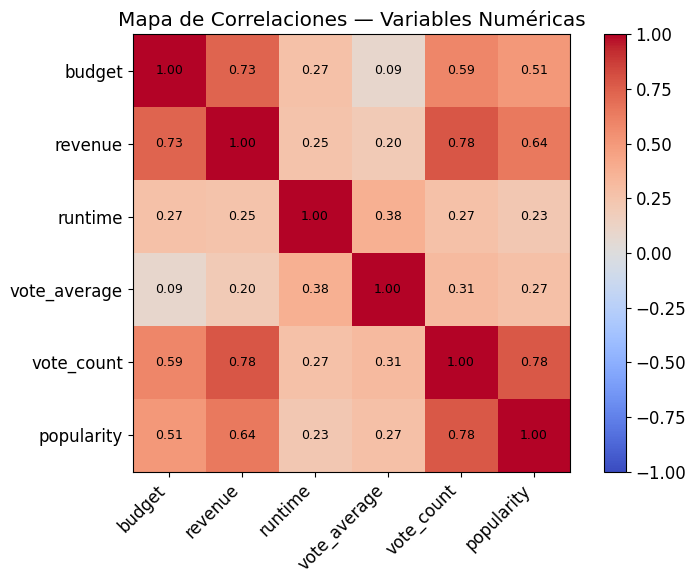

In [12]:
# Correlación de Pearson entre variables numéricas
corr_matrix = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

ax.set_xticks(range(len(cols_num)))
ax.set_yticks(range(len(cols_num)))
ax.set_xticklabels(cols_num, rotation=45, ha='right')
ax.set_yticklabels(cols_num)

# Agregar valores de correlación en las celdas
for i in range(len(cols_num)):
    for j in range(len(cols_num)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9)

ax.set_title('Mapa de Correlaciones — Variables Numéricas')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()

## 7. Hallazgos Clave

Completar con los hallazgos observados durante el EDA:

1. **Distribución de géneros:** Los géneros más frecuentes son Drama, Comedy, Thriller — esto afecta directamente qué tan bien el content-based puede distinguir películas.
2. **Valores nulos:** Identificar qué columnas tienen valores nulos y cómo manejarlos en el notebook 02.
3. **Distribución de vote_average:** Concentración alrededor de 6-7, distribución aproximadamente normal — útil para definir el umbral de "relevancia" en las métricas.
4. **Budget y revenue:** Distribuciones muy sesgadas a la derecha → confirma que se necesita transformación log1p.
5. **vote_count:** Gran varianza (1 a 14,000+) → filtrar películas con vote_count < 50 para el módulo de Collaborative Filtering.

*(Reemplazar estos puntos con los hallazgos reales del análisis)*